# Nanda 2023 Grokking — Walkthrough with Our Transformer Run

A pedagogical companion to Nanda et al. 2023, *[Progress Measures for Grokking via Mechanistic Interpretability](https://arxiv.org/abs/2301.05217)*. We use a single 1-layer transformer run we already trained — stored entirely inside this notebook's data directory — to walk through the paper's core observations: the **grokking phenomenon**, the **three-phase training decomposition**, and the **four progress measures** Nanda used to make the mechanism legible.

The run is `tf-88648a7fb8` from `experiments/compare.yaml`: `mod_add` on $p=113$, seed 42, `weight_decay=1.0` (Nanda's default), early-stopped at step 8,400 with val-acc 0.9924. Nothing in this notebook re-trains; every figure and statistic comes from the CSVs in `./02_nanda_grokking/`.

**What we can reproduce from these CSVs:** the grokking curve shape, approximate phase boundaries.  
**What we can't:** Nanda's four progress measures (restricted / excluded loss, trigonometric similarity, Gini of Fourier power). Those need model weight snapshots, which this run didn't save. §5 explains what would be needed to fill the gap.

## §0 · Setup

Load the three snapshotted files. The notebook is robust to being run from either `notebooks/` or the repo root.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

_candidates = [
    Path.cwd() / "02_nanda_grokking",                 # running from notebooks/
    Path.cwd() / "notebooks" / "02_nanda_grokking",   # running from repo root
]
DATA = next((p for p in _candidates if p.exists()), None)
if DATA is None:
    raise FileNotFoundError(
        "02_nanda_grokking/ not found — run from notebooks/ or repo root"
    )
print(f"Loading from: {DATA}")

runs    = pd.read_csv(DATA / "runs.csv")
curves  = pd.read_csv(DATA / "curves.csv")
manifest = json.loads((DATA / "manifest.json").read_text())

TF_ID = "tf-88648a7fb8"
tf_run    = runs[runs["run_id"] == TF_ID].iloc[0]
tf_curves = curves[curves["run_id"] == TF_ID].sort_values("step").reset_index(drop=True)

grok_step = int(tf_run["grok_step"])
print(
    f"Run: {TF_ID}\n"
    f"  task={tf_run['task_kind']} p={tf_run['p']} seed={tf_run['seed']} "
    f"wd={tf_run['weight_decay']} d_model={tf_run['d_model']}\n"
    f"  n_steps_planned={tf_run['n_steps_planned']} grok_step={grok_step}  "
    f"final_val_acc={tf_run['final_val_acc']:.4f}\n"
    f"  source git_sha={manifest['provenance']['git_sha']}  "
    f"device={manifest['provenance']['device']}"
)

Loading from: /Users/jakeholl/domains/phase-accumulator-network-research/notebooks/02_nanda_grokking
Run: tf-88648a7fb8
  task=mod_add p=113 seed=42 wd=1.0 d_model=128
  n_steps_planned=50000 grok_step=8400  final_val_acc=0.9924
  source git_sha=cacd8fa  device=mps


## §1 · Background — Nanda 2023 in one page

**Grokking** (Power et al. 2022) is the empirical observation that a small neural network trained on a small algorithmic task can reach near-perfect *training* loss very early, then remain at near-random *validation* accuracy for tens of thousands of steps, and then — often suddenly — transition to near-perfect validation accuracy. The mystery is: what is the network doing during the plateau?

**The Clock algorithm.** Nanda et al. mechanistically decoded a 1-layer transformer trained on $a + b \bmod p$ for $p=113$. The grokked network implements a **Fourier-basis** algorithm: each token is embedded as a rotation by $2\pi k / p$ for a small set of active integer frequencies $k$; the MLP/attention combines these rotations to form $2\pi k (a+b) / p$; the unembed (decoder) reads out the sum frequency. This is the eponymous *Clock*: addition is rotation on a circle.

**Three phases of training.** Nanda identified the following phases, delineated by their mechanistic progress measures:

1. **Memorization** (roughly steps 0 → 1.5K at $p=113$, wd=1.0): train loss drops, the model memorizes individual input pairs, no generalizing circuit has formed.
2. **Circuit formation** (~1.5K → ~10K): the Clock circuit develops — Fourier components in the embeddings grow, weight matrices gain sinusoidal structure — but the circuit is not yet *dominant* over the memorization solution. Train loss is already near-zero; val loss is still high.
3. **Cleanup** (~10K → ~14K): the memorization solution is pruned by weight decay; only the Clock circuit remains, and val loss suddenly drops.

**Four progress measures.** Nanda's key methodological contribution was defining quantities that track each phase with sharper signal than loss alone:

| # | Measure | What it measures | Needs |
|---|---|---|---|
| 1 | **Restricted loss** | Loss with only the top-K Fourier components retained | weight matrices |
| 2 | **Excluded loss**   | Loss with those same components zeroed out | weight matrices |
| 3 | **Trigonometric similarity** | Cosine similarity of learned embeddings to an ideal Fourier basis | embeddings |
| 4 | **Gini coefficient** of the embedding/unembed Fourier power spectrum | Concentration of weight mass on a few frequencies | weight matrices |

All four require direct access to the trained model. Our stored artifact is *only* the learning curves — so we can reproduce the phenomenology but not the mechanistic dissection. §5 is explicit about that gap.

## §2 · Our experiment

We trained a Nanda-style 1-layer transformer (`pan_lab/models/transformer.py`: `TransformerBaseline(d_model=128, n_heads=4, d_mlp=512)`, matching Nanda §3.1) on `mod_add` at $p=113$ with `weight_decay=1.0` and `lr=1e-3`. The config is one arm of `experiments/compare.yaml`, which pairs the transformer against a PAN baseline. The PAN companion is out of scope here — see `notebooks/01_diffusion_investigation.ipynb` for that story.

Key differences from Nanda's canonical setup:

* **Early stopping.** We stop once val-acc reaches grok threshold. Nanda runs to 50K+ so the shape past grok is visible; our training ends at step 8,400 immediately after val-acc clears 0.99.
* **No weight snapshots.** The YAML doesn't set `save_model`, so we have loss curves but no checkpointed `.pt` files.

In [2]:
# The single row of runs.csv for this transformer run.
tf_run.to_frame().T[[
    "run_id", "label", "p", "task_kind", "model_kind",
    "d_model", "seed", "weight_decay",
    "n_steps_planned", "n_steps_actual", "grok_step",
    "final_val_acc", "param_count",
]]

,run_id,label,p,task_kind,model_kind,d_model,seed,weight_decay,n_steps_planned,n_steps_actual,grok_step,final_val_acc,param_count
1,tf-88648a7fb8,tf,113,mod_add,transformer,128,42,1.0,50000,8400,8400,0.99243,227200


## §3 · The grokking phenomenon

Plot train and val loss (log-y) above val accuracy (linear-y) against training step. The green band marks the grokking region: once val-acc crossed 0.99, early-stop triggered.

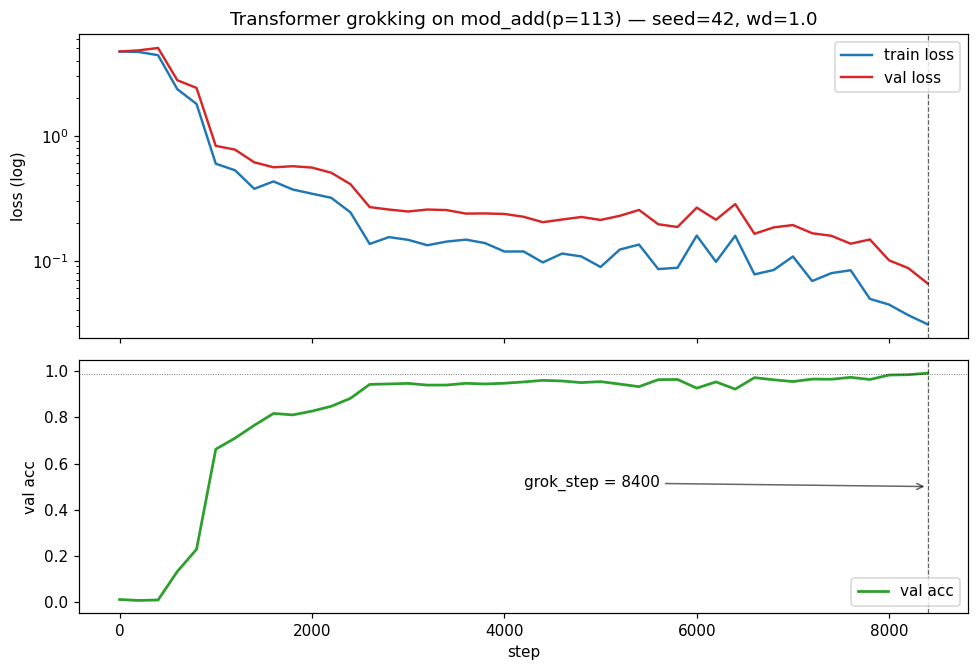

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6.2), sharex=True,
                          gridspec_kw={"height_ratios": [1.2, 1]})

ax = axes[0]
ax.plot(tf_curves["step"], tf_curves["train_loss"], label="train loss", color="C0", lw=1.6)
ax.plot(tf_curves["step"], tf_curves["val_loss"],   label="val loss",   color="C3", lw=1.6)
ax.set_yscale("log")
ax.set_ylabel("loss (log)")
ax.axvline(grok_step, color="k", lw=0.8, ls="--", alpha=0.6)
ax.axvspan(grok_step, tf_curves["step"].max(), color="tab:green", alpha=0.08)
ax.legend(loc="upper right")
ax.set_title(f"Transformer grokking on mod_add(p=113) — seed=42, wd=1.0")

ax = axes[1]
ax.plot(tf_curves["step"], tf_curves["val_acc"], color="C2", lw=1.8, label="val acc")
ax.axhline(0.99, color="k", lw=0.6, ls=":", alpha=0.6)
ax.axvline(grok_step, color="k", lw=0.8, ls="--", alpha=0.6)
ax.axvspan(grok_step, tf_curves["step"].max(), color="tab:green", alpha=0.08)
ax.annotate(f"grok_step = {grok_step}", xy=(grok_step, 0.5),
            xytext=(grok_step * 0.5, 0.5),
            arrowprops={"arrowstyle": "->", "alpha": 0.6},
            fontsize=10)
ax.set_xlabel("step")
ax.set_ylabel("val acc")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Reading the plot.** Train loss falls fast — from 4.73 (uniform over 113 classes) to below 0.6 by step 1K — while val loss lags, peaking *above* initial at step ~400 (classic overfit signature) before joining train on a slow descent. Val accuracy crawls out of near-random at step ~800, reaches 0.95 by step ~2.6K, and then edges up to cross 0.99 at step 8,400.

Compared to Nanda's Fig 1 at the same hyperparameters, this is a *compressed* grokking: at Nanda's setup train loss bottoms out within ~500 steps and val loss holds a long plateau. Here, with early-stop, we don't see the long post-train-zero plateau Nanda used to define "circuit formation." The phenomenon is present but truncated; the next section makes that explicit.

## §4 · Three-phase structure in our curve

Overlay Nanda's phase taxonomy onto the run, with the caveat that here the phases are *visual estimates* from curve shape — not grounded in progress-measure signals we'd need model weights for.

| Phase | Step range | Signal in our curve |
|---|---|---|
| **Memorization**     | 0 → ~1K   | Train loss drops sharply (4.73 → 0.6). Val loss *rises* first (4.73 → 5.04 at step 400) then turns over; val-acc is near-chance throughout. |
| **Circuit formation** | ~1K → ~7K | Train and val both improving; val-acc climbs 0.66 → 0.97 while train loss slowly anneals 0.6 → 0.08. Weight decay is shaping structure. |
| **Cleanup / grokking** | ~7K → 8.4K | Final tightening; val-acc crosses 0.99. Early-stop triggers. |

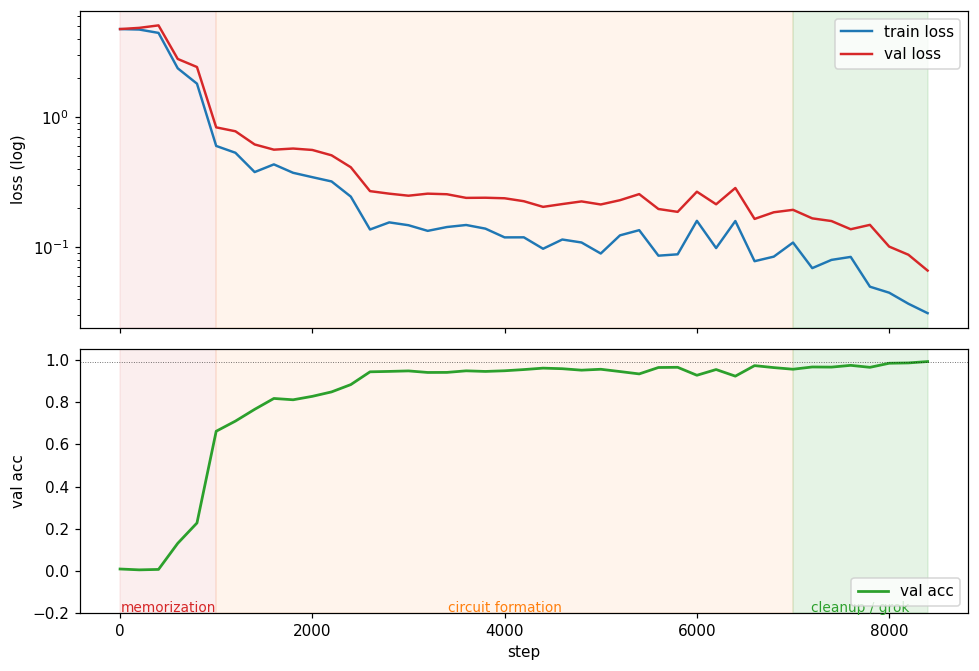

In [4]:
PHASES = [
    (0,    1000, "memorization",      "tab:red",    0.08),
    (1000, 7000, "circuit formation", "tab:orange", 0.08),
    (7000, 8400, "cleanup / grok",    "tab:green",  0.12),
]

fig, axes = plt.subplots(2, 1, figsize=(9, 6.2), sharex=True,
                          gridspec_kw={"height_ratios": [1.2, 1]})

ax = axes[0]
ax.plot(tf_curves["step"], tf_curves["train_loss"], label="train loss", color="C0", lw=1.6)
ax.plot(tf_curves["step"], tf_curves["val_loss"],   label="val loss",   color="C3", lw=1.6)
ax.set_yscale("log")
ax.set_ylabel("loss (log)")
for lo, hi, label, color, alpha in PHASES:
    ax.axvspan(lo, hi, color=color, alpha=alpha)
ax.legend(loc="upper right")

ax = axes[1]
ax.plot(tf_curves["step"], tf_curves["val_acc"], color="C2", lw=1.8, label="val acc")
ax.axhline(0.99, color="k", lw=0.6, ls=":", alpha=0.6)
for lo, hi, label, color, alpha in PHASES:
    ax.axvspan(lo, hi, color=color, alpha=alpha)
    ax.text((lo + hi) / 2, -0.14, label, ha="center", va="top", fontsize=9, color=color)
ax.set_xlabel("step")
ax.set_ylabel("val acc")
ax.set_ylim(-0.2, 1.05)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Caveat.** These boundaries are hand-placed. Nanda's measures (§5) locate the transitions precisely:

- *Memorization → circuit formation* is where **excluded loss** starts rising (the non-Fourier components become dispensable).
- *Circuit formation → cleanup* is where **restricted loss** converges to the full-model loss (the Clock circuit carries the whole solution).

With curves alone we can see *that* there are phases; we can't see *where* they are. The next section explains why.

## §5 · Progress measures — reality check

Each of Nanda's four measures reads weight matrices or embedding tensors from the trained model. We have neither, because `compare.yaml` didn't set `save_model`. Each subsection below explains what the measure means in Nanda's setup, and what we'd need to compute it here.

### 5.1 Restricted loss

Take the trained model. FFT each weight matrix along its input dimension; keep only the top $K$ Fourier bins; inverse-FFT back; evaluate validation loss with this projected model. In a grokked Clock network, restricted loss with $K{=}5$ (the number of active Clock frequencies at $p{=}113$) matches full-model loss by end of training. During memorization it is high — the Clock circuit isn't dominant yet. **Status: not computable here** — requires trained weight tensors.

### 5.2 Excluded loss

The converse: zero out the top-$K$ Fourier components and evaluate. Starts low (the non-Fourier components carry the memorized solution) and rises as weight decay prunes them. **Status: not computable here** — same reason.

### 5.3 Trigonometric similarity

Cosine similarity between learned token embeddings and an ideal Fourier basis of dimension $p$. Starts near zero and rises as the circuit forms. The embedding tensor is $W_E \in \mathbb{R}^{(p+1) \times d_{\text{model}}}$; we'd read it directly and project onto the Fourier basis. **Status: not computable here** — no `.pt`.

### 5.4 Gini coefficient of Fourier power

Measures how concentrated the power spectrum of the embedding/unembed matrices is across frequencies. A grokked Clock network puts nearly all mass on $\sim 5$ frequencies, so Gini approaches 1; a memorizing network is more uniform, so Gini stays low. **Status: not computable here** — requires the same weight tensors.

### What would fill the gap

Add `save_model: true` under `base:` in `experiments/compare.yaml` (the flag is read by `pan_lab.trainer`) and re-run this single seed — CPU training to step 8,400 took 16.3 s on this machine. Point the notebook at the resulting `model.pt`. `pan_lab.analysis.fourier_concentration` (see `pan_lab/analysis.py`) is the closest helper we already have: it returns the fraction of a matrix's spectral energy in its top-$K$ FFT bins, which can be adapted into Gini and restricted-loss computations.

## §6 · Conclusions and next steps

- The stored transformer run **does** show the grokking signature qualitatively: train loss falls before val loss, val accuracy catches up late, and the final transition is sharp. It is, however, a *compressed* example — early stop truncates what would otherwise be a longer plateau at Nanda's full 50K-step budget.
- The **three-phase structure** is visible in curve shape but cannot be precisely located without Nanda's progress measures, which need weight tensors we didn't save.
- **To fully replicate Nanda's mechanistic picture**: enable `save_model` in `compare.yaml`, rerun one seed (~16 s), and post-hoc-analyze the resulting `.pt`. `pan_lab.analysis.fourier_concentration` is the existing primitive closest to what's needed.
- **For the PAN angle on the same phenomenon**, see `notebooks/01_diffusion_investigation.ipynb`. That notebook uses 276 grokked PAN runs to localize a three-phase structure using PAN-native metrics (clock compliance, active frequency count, gate-probe accuracy), reaching conclusions consistent with Nanda's three-phase framing but through a different mechanism (mix-layer pruning rather than circuit-vs-memorization competition).
- **For how all of the above is framed in the paper**, see `docs/drafts/04_pan_paper_v4.md` and the companion draft `docs/drafts/02_pan_paper_companion.md`.